פרויקט סיכום תכנות מתקדם בפייתון

I. בחירת סט נתונים

״.UCI Machine Learning Repository את קובץ הנתונים שלי לקחתי מהמקור שניתן״
הדאתא שלי מתאר קובץ שלקוח מתוך מאגר בנק. הקובץ מתאר קמפיין שנעשה ללקוחות הבנק לעידוד לקוחות לפתיחת פיקדון בבנק (כך תואר באתר המקור).
 מטרת המחקר שלי היא ניתוח עסקי של הנתונים על מנת להגדיל את מספר הלקוחות שפותחים פיקדון בבנק ובכך למקד את משאביי בהתאם כארגון עיסקי.



II. קריאת נתונים ותחקור ראשוני

In [8]:
import pandas as pd

df = pd.read_csv("bank_marketing.csv", sep=";")
df.shape

(41188, 21)

In [9]:
df.columns.tolist()

['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'day_of_week',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y']

In [10]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

 משום ששאר העמודות מתארים את מאפייני לקוחות הבנק "y" אבדוק את העמודה האחרונה בשם 

In [12]:
df["y"].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

  העמודה מחזירה תוצאה בינארית - כן/לא ולכן זוהי עמודת המטרה. אני רוצה להתמקד בה ולבדוק בניתוח הנתונים מה השפיע על הלקוחות שלא נרשמו לפיקדון.

In [14]:
df.isna().sum()
categorial_cols = df.select_dtypes(include="object").columns
df[categorial_cols].eq("unknown").sum()

job             330
marital          80
education      1731
default        8597
housing         990
loan            990
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
dtype: int64

III. הבנת נתונים EDA

#סטטיסטיקות תיאוריות

In [17]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


התכונות הבולטות בסטטיסטיקות :
גיל(שורה 1) - ניתן לראות שהגיל הממוצע הוא 40 , כלומר רוב הקמפיין ממוקד באוכלוסיה שהיא בוגרת יחסית בגילאי העבודה וניתן להסיק מזה על אופי השיחה שאמור להיות ממוקד יותר, משכנע יותר(משום שבעלי ניסיון לרוב בפקדונות וניהול כספים) ומקצועי. 
משך שיחה - (שורה 2) ניתן לראות שהמקסימום הוא כמעט 5000 שניות. כלומר ישנן שיחות ארוכות במיוחד שהן חריגות ומצביעות על לקוחות קשים לשכנוע. 
פניות קודמות (שורה 5) - ניתן לראות שהנתונים אפסיים כלומר לרוב הלקוחות לא היו פניות קודמות והם לקוחות חדשים עבור הבנק מה שמדגיש את חשיבות אופן ניהול השיחה וגם את משך השיחות


In [19]:
categorial_cols = df.select_dtypes(include="object").columns
for col in categorial_cols:
    print(f"Column: {col}")
    display(df[col].value_counts())

Column: job


job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Column: marital


marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Column: education


...

day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64

Column: poutcome


poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

Column: y


y
no     36548
yes     4640
Name: count, dtype: int64

#שאילתות

In [21]:
df.groupby("y")["duration"].mean()

y
no     220.844807
yes    553.191164
Name: duration, dtype: float64

ממוצע משך שיחה לפי תוצאת הקמפיין - ניתן לראות שבשיחות מאוד ארוכות רוב השיחות מסתיימות בתוצאה חיובית. ניתן להסיק מכך שיש משמעות לשכנוע והתעקשות מצד נציג הבנק, לתת מידע נרחב ולא לוותר על הפוטנציאל העסקי של הלקוח.

In [23]:
(df["y"].eq("yes")).groupby(df["job"]).mean().sort_values(ascending=False)

job
student          0.314286
retired          0.252326
unemployed       0.142012
admin.           0.129726
management       0.112175
unknown          0.112121
technician       0.108260
self-employed    0.104856
housemaid        0.100000
entrepreneur     0.085165
services         0.081381
blue-collar      0.068943
Name: y, dtype: float64

חלוקת ביקוש עפי מקצועות- ניתן לראות שבמקצועות מסוימים כמו סטודנטים ופנסיונרים יש יותר היענות לפיקדון בנקאי.עוזר להבין מי הוא קוב קהל היעד שלי בקמפיין ואיפה בעיקר למצות את משאביי. (שיחות,שיחות חוזרות, פרסומים אישיים,ואולי אפילו גם הטבות) 

In [25]:
(df["y"].eq("yes")).groupby(df["month"]).mean().sort_values(ascending=False)

month
mar    0.505495
dec    0.489011
sep    0.449123
oct    0.438719
apr    0.204787
aug    0.106021
jun    0.105115
nov    0.101439
jul    0.090466
may    0.064347
Name: y, dtype: float64

אחוזי הצלחה עפי חודשים - ניתן לראות שבחודשים מרץ, דצמבר, ספטמבר ואוקטובר אחוזי ההצלחה משמעותית גבוהים יותר מחודש מאי למשל. יכול להיות שיש קשר בין תקופות חגים (בנק בפורטוגל) / חודשי חופשות שאלו מועדים בעלי הוצאות רבות. 

In [27]:
(df["y"].eq("yes")).groupby(df["pdays"] < 999).mean()

pdays
False    0.092582
True     0.638284
Name: y, dtype: float64

אחוזי הצלחה בשיחות ללקוחות קיימים -ניתן לראות שאחוזי ההצלחה בשיחות חוזרות ללקוחות קיימים מקמפיינים בעבר גבוהים מאוד ולכן על הנציגים הבנקאים למצות את כללל הפוטנציאל מהלקוחות ולבצע שיחות ללקוחות שכבר קיימים והיו בקמפיינים בעבר . 

#גרפים 

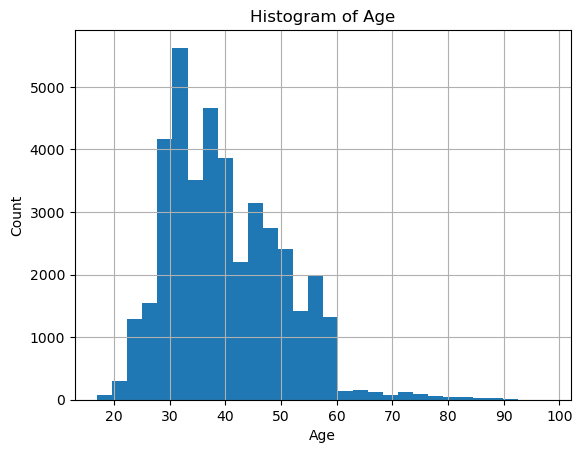

In [30]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["age"], bins=30)
plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)

ניתן לראות עפי הגרף שרוב הלקוחות הפותחים פיקדון הם בגילאי ה30-40. 

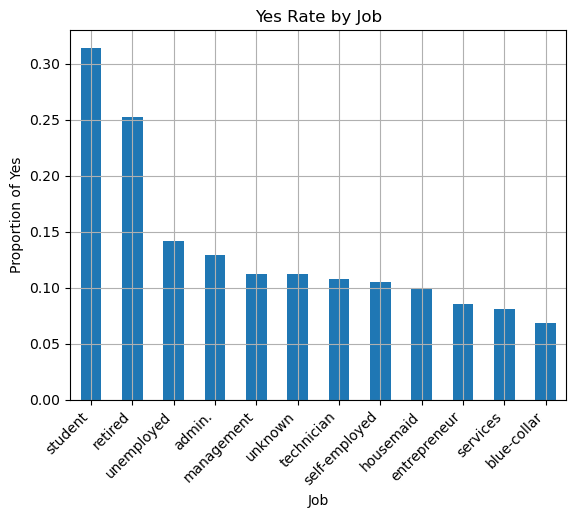

In [32]:
yes_rate_by_job = (df["y"].eq("yes")).groupby(df["job"]).mean().sort_values(ascending=False)

plt.figure()
yes_rate_by_job.plot(kind="bar")
plt.title("Yes Rate by Job")
plt.ylabel("Proportion of Yes")
plt.xlabel("Job")
plt.xticks(rotation=45, ha="right")
plt.grid(True)

ניתן לראות שהתעסוקה משפיעה על ההחלט לפתוח פיקדון בנקאי - רוב הנענים הם פנסיונרים וסטודנטים. סטודנטים הם אוכלוסיה ברובה צעירה ובתחילת דרכה הפיננסית וברוב המקרים גם לא עובדים במשרה מלאה בתקופת הלימודים ולכן ההצעה של נציג הבנק ״לאכלס״ את הכסף הקיין לתקופה שבמילא היא תקופת הלימודים שלה הסטודנט כנראה היא ״פיתוי קל״ עבורם. פנסיונרים הינה אוכלוסיה מבוגרת שלא תמיד חשופה לתוכן מגוון ברשתות/ פלטפורמות שונות ועל כן שיחת טלפון עם נציג בנקאי יכולה לחדש להם על דברים מסוימים ולגרום להם להסכים להצטרף. 

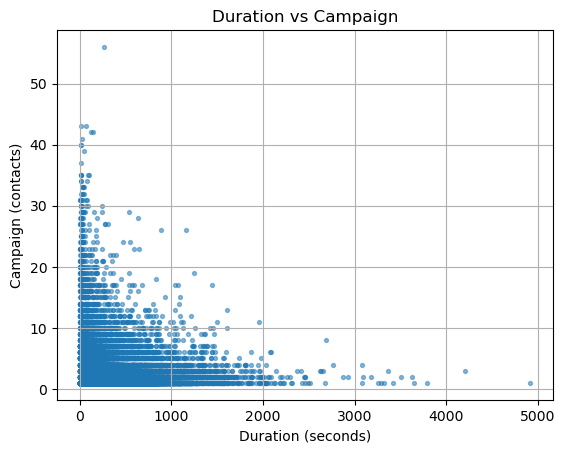

In [34]:
plt.figure()
plt.scatter(df["duration"], df["campaign"], s=8, alpha=0.5)
plt.title("Duration vs Campaign")
plt.xlabel("Duration (seconds)")
plt.ylabel("Campaign (contacts)")
plt.grid(True)

קשר בין מס׳ פניות לאחוזי הצלחה- ניתן לראות שרוב הנקודות מרוכזות בפניות קצרות (מתחת ל1000) ויש מעט מאו נקודות מעל 2000 .
כשיש המון פניות (עמודת אנכית) הן בדרך כלל מאוד קצרות. 
וזה מראה על קשר לא חיובי- ככל שמבצעים יותר פניות חוזרות משך השיחה בפועל מתקצר וניתן להסיק מכך שהלקוח אינו מעוניין. 
לעומת זאת שהשיחות ארוכות התשובה היא לרוב חיובית וזוהי גם שיחה ראשונית.

IV. השוואת אלגוריתמי מיון וחיפוש

In [37]:
import numpy as np
import pandas as pd

In [38]:
arr_10k = np.random.randint(0, 1000000, 10_000)
arr_15k = np.random.randint(0, 1000000, 15_000)#במקום 100,000 כי ההרצה נתקעת
arr_20k = np.random.randint(0, 1000000, 20_000) #במקום מיליון כי ההרצה נתקעת 
arr_age = df["age"].values

In [39]:
def bubble_sort(arr):
    a = arr.copy()
    for i in range(len(a)-1):
        for j in range(len(a)-1-i):
            if a[j] > a[j+1]:
                a[j], a[j+1] = a[j+1], a[j]
    return a

In [40]:
%%time
bubble_sort(arr_10k)

CPU times: user 34.3 s, sys: 576 ms, total: 34.9 s
Wall time: 43.6 s


array([    27,     35,     55, ..., 999627, 999793, 999984])

In [41]:
%%time
bubble_sort(arr_15k)

CPU times: user 1min 15s, sys: 1.21 s, total: 1min 16s
Wall time: 1min 37s


array([    12,     41,    173, ..., 999718, 999863, 999996])

In [42]:
%%time
bubble_sort(arr_20k)

CPU times: user 2min 17s, sys: 2.26 s, total: 2min 19s
Wall time: 2min 54s


array([    19,     72,     88, ..., 999870, 999893, 999993])

In [43]:
%%time
bubble_sort(arr_age)

CPU times: user 10min 52s, sys: 9.87 s, total: 11min 1s
Wall time: 14min 34s


array([17, 17, 17, ..., 95, 98, 98])

In [44]:
%time
np.sort(arr_10k)

CPU times: user 4 μs, sys: 1 μs, total: 5 μs
Wall time: 19.8 μs


array([    27,     35,     55, ..., 999627, 999793, 999984])

In [45]:
%time 
np.sort(arr_15k)

CPU times: user 4 μs, sys: 0 ns, total: 4 μs
Wall time: 7.87 μs


array([    12,     41,    173, ..., 999718, 999863, 999996])

In [46]:
%time
np.sort(arr_20k)

CPU times: user 3 μs, sys: 1e+03 ns, total: 4 μs
Wall time: 7.15 μs


array([    19,     72,     88, ..., 999870, 999893, 999993])

In [47]:
%time
np.sort(arr_age)

CPU times: user 5 μs, sys: 1 μs, total: 6 μs
Wall time: 9.06 μs


array([17, 17, 17, ..., 95, 98, 98])

In [48]:
results = pd.DataFrame({
    "Array": ["Random 10k", "Random 15k", "Random 20k", "Age (≈41k)"],
    "Bubble Sort (Wall time)": ["31.5 s", "1m 15s", "2m 20s", "9m 18s"],  
    "NumPy Sort (Wall time)":  ["0.00001 s", "0.000012 s", "0.000012 s", "0.000009 s"]
})
results

,Array,Bubble Sort (Wall time),NumPy Sort (Wall time)
0,Random 10k,31.5 s,0.00001 s
1,Random 15k,1m 15s,0.000012 s
2,Random 20k,2m 20s,0.000012 s
3,Age (≈41k),9m 18s,0.000009 s


ניתן להגיד על ההשוואה בין הביצועים שרואים בבירור ששימוש בנאמפיי הוא יעיל ומהיר יותר . אלגורתים המיון באבל סורט אומנם טוב כדי להבין כיצד מיון עובד, אך בפועל לא פרקטי לניתוח מאגרי נתונים גדולים ופרויקטים בעלי נתונים רבים. 

Data Preparation - נתונים עיבוד .V

#השלמת ערכים חסרים

In [52]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [53]:
categorial_cols = df.select_dtypes(include="object").columns
unknown_per_col = df[categorial_cols].apply(lambda s: s.eq("unknown").sum()).sort_values(ascending=False)
unknown_per_col
rows_with_unknown = (df[categorial_cols] == "unknown").any(axis=1)
rows_with_unknown.sum()

10700

In [54]:
df_clean = df.loc[~rows_with_unknown].reset_index(drop=True)

In [55]:
(df.shape, df_clean.shape)

((41188, 21), (30488, 21))

In [56]:
num_cols = df_clean.select_dtypes(include="number").columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

#עמודות חדשות

קטוגריית לקוחות חוזרים

In [59]:
df_clean["contact_before"] = (df_clean["pdays"] < 999).astype(int)

קטגוריות גיל 

In [61]:
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[17, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "60+"]
)

קטגורית יכולת התחייבות

In [63]:
df_clean["any_loan"] = ((df_clean["housing"].eq("yes")) | (df_clean["loan"].eq("yes"))).astype(int)

In [64]:
df_clean.tail(0).columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'contact_before',
       'age_group', 'any_loan'],
      dtype='object')

#המרה 

In [66]:
TARGET = "y"
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].map({"no": 0, "yes": 1}) 
categorial_cols = X.select_dtypes(include="object").columns
X_encoded = pd.get_dummies(X, columns=categorial_cols, drop_first=True)
(X.shape, X_encoded.shape)
X_encoded.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,59,139,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


In [67]:
#נרמול

In [122]:
TARGET = "y"
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].map({"no": 0, "yes": 1})
ategorical_cols = X.select_dtypes(include=["object", "category"]).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_encoded.select_dtypes(exclude="number").columns

Index(['job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed',
       'poutcome_nonexistent', 'poutcome_success', 'age_group_31-45',
       'age_group_46-60', 'age_group_60+'],
      dtype='object')

In [124]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET].map({"no": 0, "yes": 1})
categorical_cols = X.select_dtypes(include=["object", "category"]).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_encoded.select_dtypes(exclude="number").columns

Index(['job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed',
       'poutcome_nonexistent', 'poutcome_success', 'age_group_31-45',
       'age_group_46-60', 'age_group_60+'],
      dtype='object')

In [126]:
X_encoded = X_encoded.apply(pd.to_numeric, errors="raise")
X_encoded.select_dtypes(exclude="number").columns

Index(['job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'marital_married',
       'marital_single', 'education_basic.6y', 'education_basic.9y',
       'education_high.school', 'education_illiterate',
       'education_professional.course', 'education_university.degree',
       'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone',
       'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar',
       'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon',
       'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed',
       'poutcome_nonexistent', 'poutcome_success', 'age_group_31-45',
       'age_group_46-60', 'age_group_60+'],
      dtype='object')

In [128]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)
X_encoded.select_dtypes(exclude="number").columns

Index([], dtype='object')

In [130]:
mins = X_encoded.min(axis=0)
rng = X_encoded.max(axis=0) - mins
rng = rng.replace(0, 1)
X_normalized = (X_encoded - mins) / rng

X_normalized.describe().T[["min", "max"]].head()

,min,max
age,0.0,1.0
duration,0.0,1.0
campaign,0.0,1.0
pdays,0.0,1.0
previous,0.0,1.0


I. אלגוריתמי למידה

#למידה לא מונחית 

In [134]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

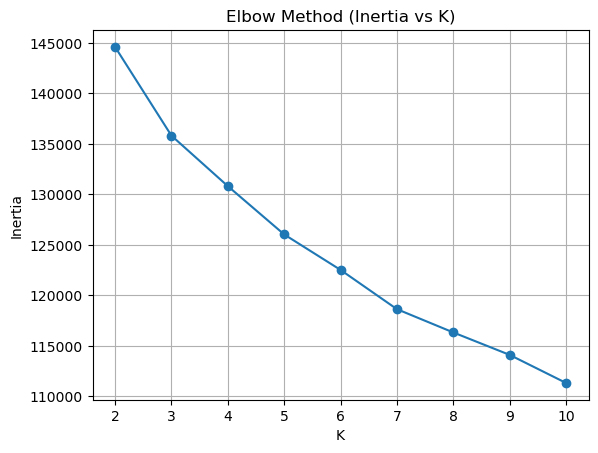

In [136]:
K_range = range(2, 11)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_normalized)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker='o')
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.grid(True)

ValueError: x and y must have same first dimension, but have shapes (9,) and (27,)

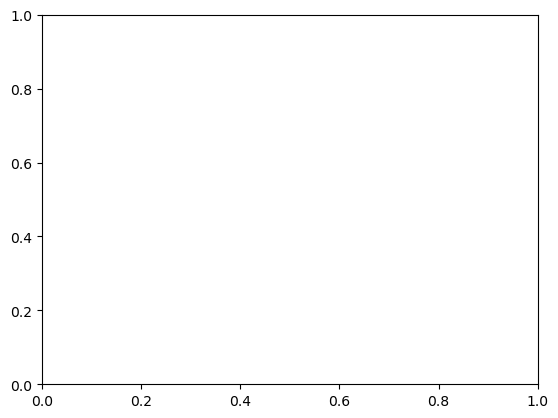

In [158]:
ssil_scores = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_normalized)
    sil_scores.append(silhouette_score(X_normalized, labels))

plt.figure()
plt.plot(list(K_range), sil_scores, marker='o')
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(True)
best_k = int(pd.Series(sil_scores, index=K_range).idxmax())
print("optimal:", best_k)

In [ ]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_normalized)

df_clusters = df_clean.copy()
df_clusters["Cluster"] = clusters
df_clusters["y_bin"] = y.values


In [ ]:
plt.figure()
for c in sorted(df_clusters["Cluster"].unique()):
    sub = df_clusters[df_clusters["Cluster"] == c]
    plt.scatter(sub["age"], sub["duration"], s=10, alpha=0.6, label=f"Cluster {c}")
plt.title("Clusters on Age vs Duration")
plt.xlabel("Age")
plt.ylabel("Call Duration (sec)")
plt.legend()
plt.grid(True)
plt.show()

הקלאסטרים בעצם מחלקים את הלקוחות לקבוצות עם התנהגות דומה.
זה מאפשר לארגו להתאים מסרים שיווקיים שונים לכל קבוצה ,להשקיע יותר משאבים בקבוצות עם פוטנציאל גבוה
ולהבין אילו קבוצות כמעט ולא נענות — ולצמצם פנייה אליהן.
למשל. לקוחות צעירים עם שיחות קצרות לרוב לא נענים לעומת לקוחות בגילאי ביניים שהשיחות איתם ארוכות יותר ויש אחוזי היענות גבוהים יותר. ניתן להסיק מבך שיש הבדל מהותי באופי הלקוחות והדרך בה הנציג צריך לגשת לכל אוכלוסיה. 

#למידה  מונחית

In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

(X_train.shape, X_test.shape)

((24390, 52), (6098, 52))

In [143]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,      
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [144]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

y_pred = rf.predict(X_test)
pd.Series({"accuracy": accuracy_score(y_test, y_pred)})
pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).T
pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["True 0","True 1"],
    columns=["Pred 0","Pred 1"]
)

,Pred 0,Pred 1
True 0,5114,212
True 1,395,377


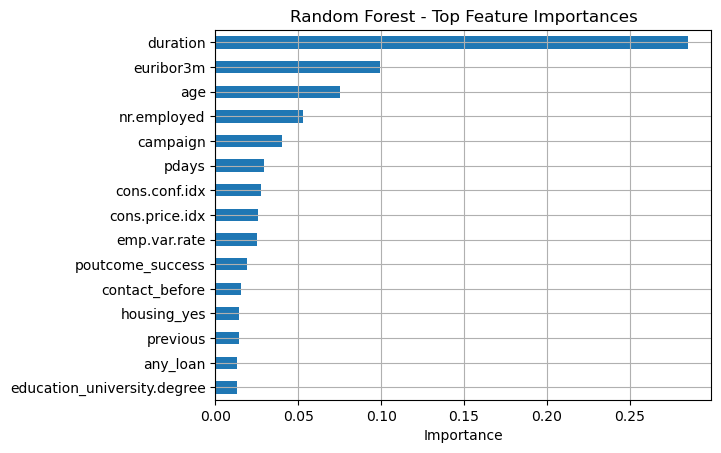

In [145]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(15).to_frame("importance")

plt.figure()
importances.head(15).iloc[::-1].plot(kind="barh")
plt.title("Random Forest - Top Feature Importances")
plt.xlabel("Importance")
plt.grid(True)

In [ ]:
ניתן לראות ש3 המאפיינים המשפיעים והחשובים ביותר הם: משך השיחה, מדד כלכלי(ריבית בנקאית לפיקדון),וגיל הלקוח. תובנות עבור הארגון הן לא תלויות רק במאפיינים טכניים אלא גם התנהגותיים ועל כן חשוב מאוד להפיק לקחים וליישם אותם בקרב הנציגים. 
משך השיחה (Duration): זהו המשתנה המשפיע ביותר. נצפה כי ככל שמשך השיחה עם הלקוח ארוך יותר, כך עולה ההסתברות להצלחת השיחה ולהצטרפות הלקוח. הדבר עשוי להצביע על כך ששיחות ארוכות מאפשרות למוקדן להציג את היתרונות, לענות על התנגדויות ולבסס אמון עם הלקוח.
ריבית euribor לשלושה חודשים (Euribor3m): משתנה כלכלי חיצוני שנמצא גם הוא בעל השפעה גבוהה. ריבית גבוהה עשויה לגרום ללקוחות להסס יותר, ואילו ריבית נמוכה יוצרת הזדמנות אטרקטיבית יותר להצטרפות לפיקדון חיסכון. כלומר, משתנים מאקרו־כלכליים משפיעים על התנהגות הלקוחות.
גיל הלקוח (Age): הגיל נמצא כגורם נוסף בעל משמעות. ניתן להסיק כי קבוצות גיל שונות מגיבות באופן שונה להצעות הבנק – לדוגמה, צעירים נוטים פחות להתחייב למוצרי חיסכון לטווח ארוך, בעוד לקוחות מבוגרים רואים בהם אמצעי חשוב ליציבות פיננסית.